![ATARRI logos](img/logos.png)

# 3.3 MPLNET lidar vs MONARCH dust forecast comparison: Daily Plots

#### Objective

The objective of this notebook is to produce daily plots of the extinction averages of MONARCH and MPLNET and compare both across the vertical profile.

## Importing libraries and data

With our processed datasets, we can now begin creating plotting comparisons. For this part of the exercise, we want to look at the daily average of dust extinction. Therefore, we will create daily plots showing the averaged dust extinction at each altitude level. To achieve this, we will require custom functions from our `VT3-functions.ipynb` file, and we will also need to load both our MONARCH and MPLNET extinction csv outputs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
from IPython.utils.io import capture_output
with capture_output():
    %run ../functions/VT3-functions.ipynb

In [3]:
mplnet_filtered_path = '../csv/MPLNET_Barcelona_20250304_20250308_filtered.csv'
monarch_path = '../csv/MONARCH_Barcelona_20250304_20250308.csv'
mplnet_filtered_df = pd.read_csv(mplnet_filtered_path)
monarch_df = pd.read_csv(monarch_path)

## Calculating daily average

To facilitate our calculations, we will use the `daily_average()` function. This function will calculate our daily average according to the input average type, which can include all timesteps or those between 03:00:00 and 21:00:00. In our case, we will input `from 3 to 21` for both MPLNET and MONARCH. Below you can see the result: a data frame with the daily averages at each vertical level.

In [4]:
#Processing MPLNET
mplnet_avg = daily_average(mplnet_filtered_df, 'all day')

#Processing MONARCH
monarch_avg = daily_average(monarch_df, 'all day')

In [5]:
monarch_avg

,0.00,250.00,500.00,750.00,1000.00,1500.00,2000.00,3000.00,4000.00,5000.00,6000.00,8000.00,10000.00,12000.00
time,,,,,,,,,,,,,,
2025-03-04,0.000002,0.000002,0.000010,0.000019,0.000029,0.000043,0.000035,0.000018,0.000006,0.000002,0.000001,5.533791e-08,1.844675e-11,2.542989e-16
2025-03-05,0.000003,0.000004,0.000010,0.000025,0.000038,0.000047,0.000044,0.000015,0.000009,0.000003,0.000002,6.979854e-08,8.451363e-11,2.228948e-15
2025-03-06,0.000004,0.000005,0.000010,0.000016,0.000021,0.000030,0.000028,0.000028,0.000015,0.000008,0.000006,1.752711e-06,2.839790e-10,3.007783e-15
2025-03-07,0.000001,0.000003,0.000004,0.000005,0.000006,0.000012,0.000013,0.000019,0.000016,0.000007,0.000005,1.403953e-06,1.945384e-11,5.496049e-14


In [12]:
mplnet_avg = mplnet_avg.drop(mplnet_avg.index[[4]])
mplnet_avg

,199.95,274.90,349.84,424.79,499.74,574.69,649.64,724.58,799.53,874.48,...,29429.71,29504.66,29579.61,29654.56,29729.51,29804.45,29879.40,29954.35,30029.30,30104.25
time,,,,,,,,,,,,,,,,,,,,,
2025-03-04,NaN,NaN,NaN,0.000847,0.000960,0.001921,0.003585,0.005829,0.007077,0.006517,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05,NaN,NaN,NaN,0.000014,0.000008,0.000411,0.000993,0.002724,0.003438,0.003757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-06,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Pre-plotting variable set up

Currently, the altitudes of our data frames are not standardised: MPLNET has more altitude levels than MONARCH. Therefore, we will need to choose one of the two to display in plotting.

We will use the same altitude display of MONARCH, as it has a cleaner structure and its vertical profile is enough to showcase our data of interest.

To proceed with the plotting, we will store the altitudes as arrays.

In [13]:
mplnet_altitude_levels = mplnet_filtered_df.columns[1:].astype(float).to_numpy()
mplnet_altitude_levels = np.array(mplnet_altitude_levels)

monarch_altitude_levels = monarch_df.columns[1:].astype(float).to_numpy()
monarch_altitude_levels = np.array(monarch_altitude_levels)

We also need to convert our extinction data to arrays, and extract the dates as a list.

In [14]:
mplnet_avg_array = np.array(mplnet_avg)
mplnet_time = mplnet_avg.index.to_list()

In [15]:
mplnet_time

[Timestamp('2025-03-04 00:00:00'),
 Timestamp('2025-03-05 00:00:00'),
 Timestamp('2025-03-06 00:00:00'),
 Timestamp('2025-03-07 00:00:00')]

In [16]:
monarch_avg_array = np.array(monarch_avg)
monarch_time = monarch_avg.index.to_list()

## Plotting daily averages

We will now create our MONARCH vs MPLNET plot body. We will structure it with two columns and three rows for easier readability. We also need to make sure to display our extinction values in the same units, so we will convert MONARCH to `/km`. 

The x-axis represents the extinction values, and the y-axis represents the altitude levels. MPLNET extinction is shown as a green line, while MONARCH is shown as a dotted blue line. In case we do not have any available filtered MPLNET data for a specific day, the plot will be painted in a dark gray background

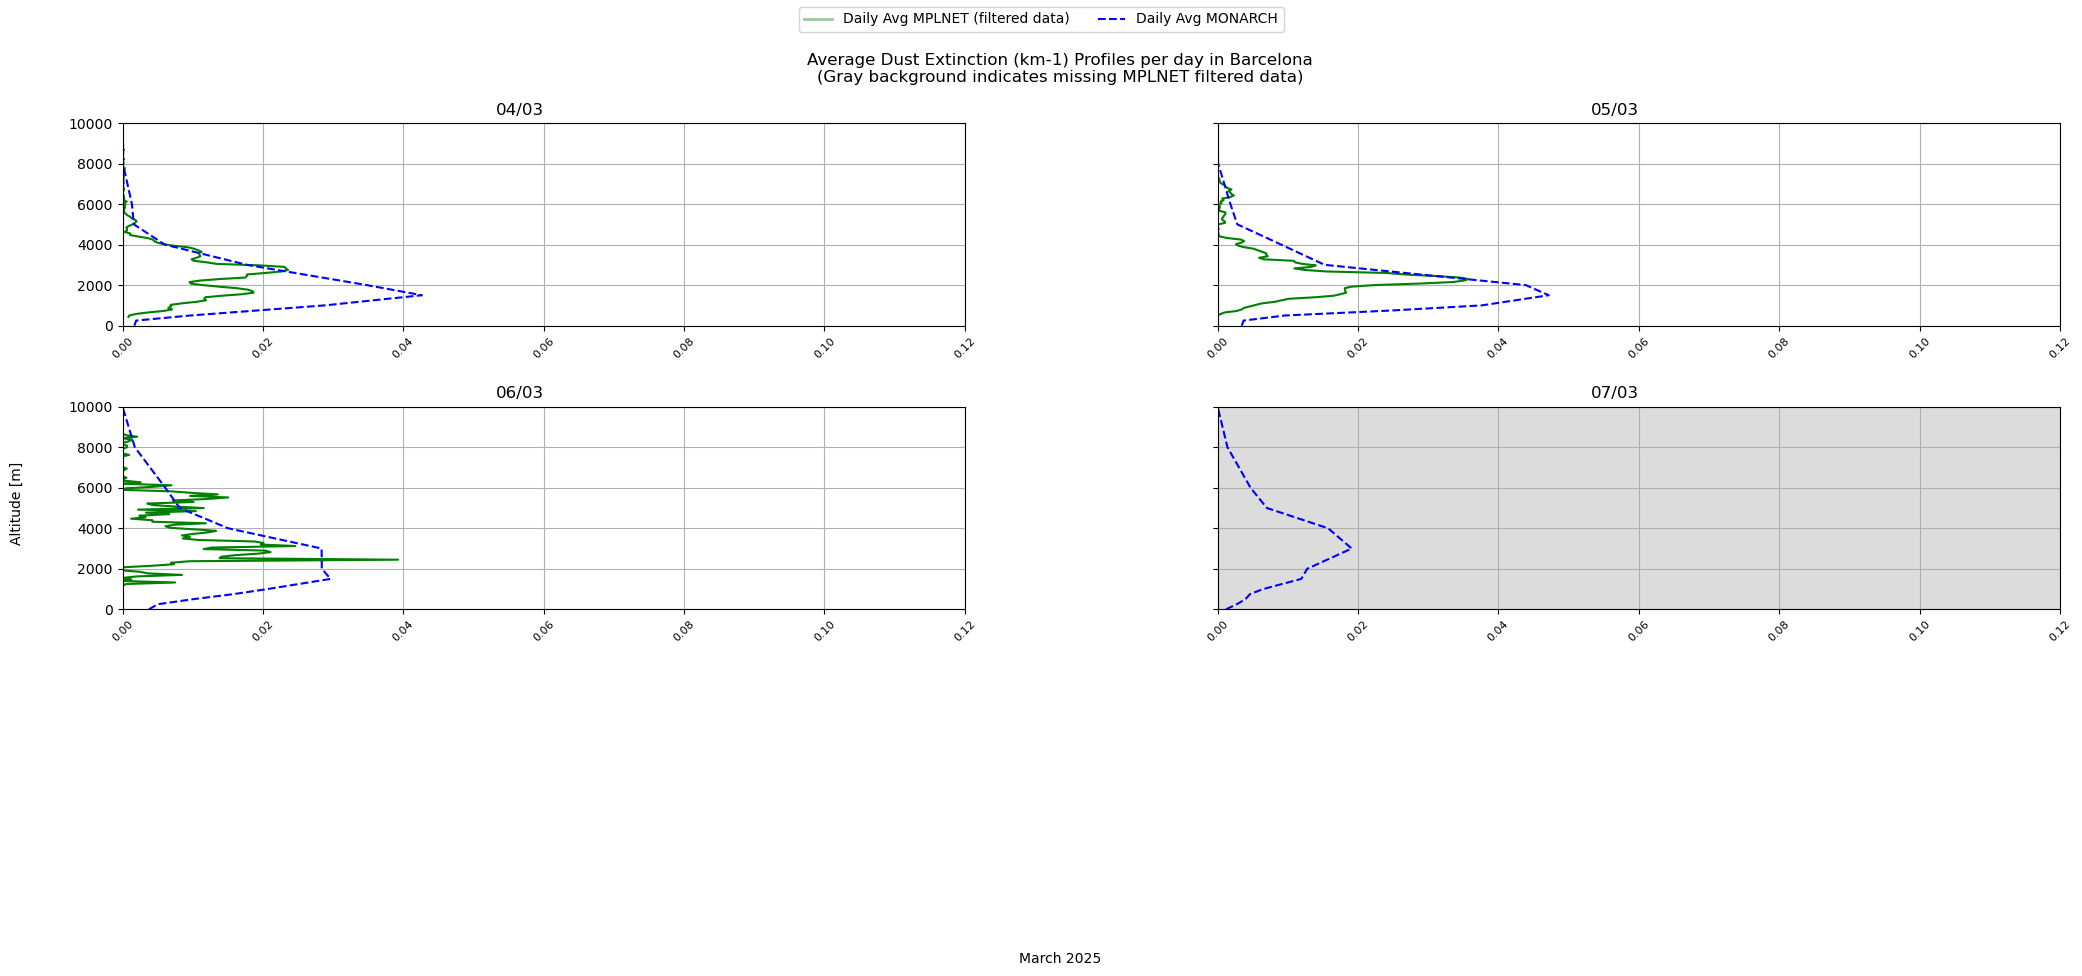

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(25, 10), sharey=True)
fig.subplots_adjust(wspace=0.3, hspace=0.4)  # Adjust space between plots

axes = axes.flatten()

mplnet_line, = plt.plot([], [], linewidth=2, color='green', alpha=0.4, label='Daily Avg MPLNET (filtered data)')  # Empty line for legend
monarch_line, = plt.plot([], [], color='blue', linestyle='dashed', label='Daily Avg MONARCH')  # Empty line for legend


for i, (ax, time) in enumerate(zip(axes, mplnet_time)):
    if np.isnan(mplnet_avg_array[i]).all(): # if we have no available MPLNET data, set the background colour to gray.
        ax.set_facecolor("gainsboro") 
    ax.plot(mplnet_avg_array[i], mplnet_altitude_levels, color='green')
    
    ax.plot(monarch_avg_array[i]*10**3, monarch_altitude_levels, color='blue', linestyle='dashed') # convert MONARCH units to /km
    ax.set_title(time.strftime('%d/%m'), ha='right')
    ax.set_ylim(0, 10000)  # Altitude range
    ax.set_xlim(0, 0.12) # Extinction range
    ax.grid(True) # display a grid
    ax.tick_params(axis='x', labelsize=8, rotation=45)

for j in range(len(mplnet_time), len(axes)):
    axes[j].axis('off')

fig.text(0.5, 0.04, "March 2025", ha="center")
fig.text(0.08, 0.5, "Altitude [m]", va="center", rotation="vertical")
plt.suptitle("Average Dust Extinction (km-1) Profiles per day in Barcelona\n(Gray background indicates missing MPLNET filtered data)", y=0.95)

fig.legend(handles=[mplnet_line, monarch_line], loc='upper center', ncol=3, fontsize=10)

plt.show()

As you can see, while we are able to compare both MONARCH and MPLNET in the first days of the dust event, we have no QA filtered observational data on March 7 and 8, which is an important limitation in our comparison.

## References and further reading

The analysis, main script and auxiliary functions of this notebook have been adapted from their original version, provided by Carlotta Gilè (BSC-CNS). 

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT3-2-MONARCH_extinction.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT3-4-VIIRS_MAPIES.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>